# IBM HR Analytics — Employee Attrition & Performance

## 1. Data Loading

In [1]:
import sys
!{sys.executable} -m pip install kagglehub seaborn matplotlib pandas numpy scikit-learn imbalanced-learn xgboost shap lime

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
# Download dataset
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
print("Path to dataset files:", path)

Path to dataset files: /Users/shazebata/.cache/kagglehub/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/versions/1


In [3]:
import os

csv_path = os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [4]:
# Drop constant and ID columns — zero predictive value
df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'], inplace=True)
print("Remaining columns:", df.shape[1])
df.head()

Remaining columns: 31


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


## 2. EDA

In [5]:
# Basic info, dtypes, missing values
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDescriptive Stats:")
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0


In [6]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Attrition')  # exclude target

print("Numerical:", numerical_cols)
print("\nCategorical:", categorical_cols)

Numerical: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


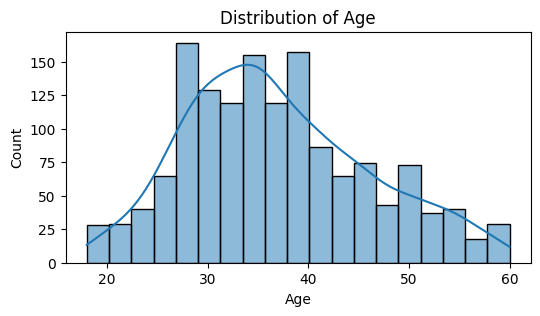

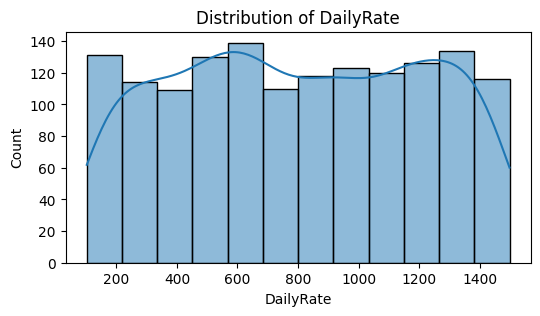

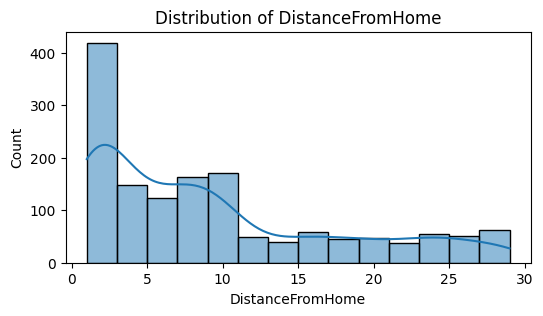

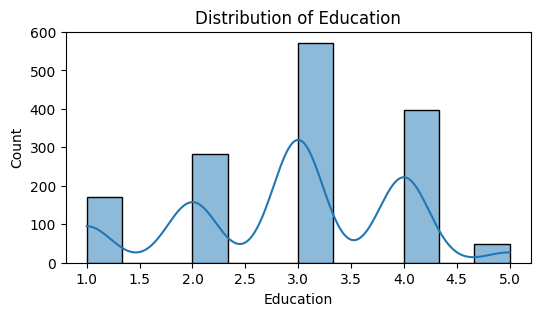

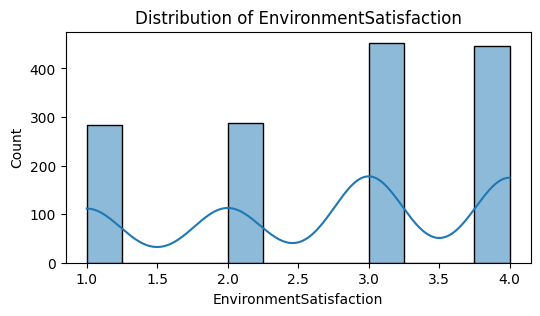

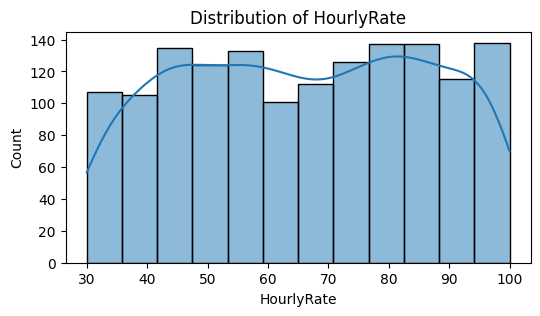

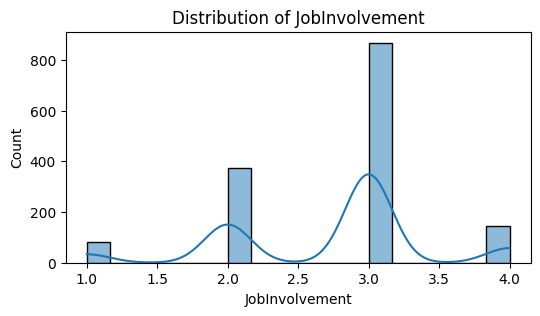

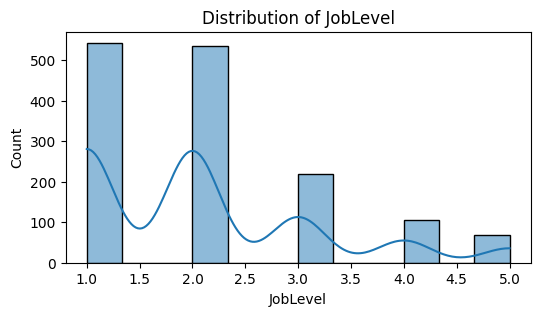

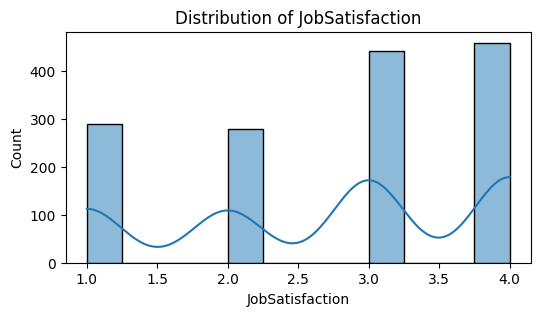

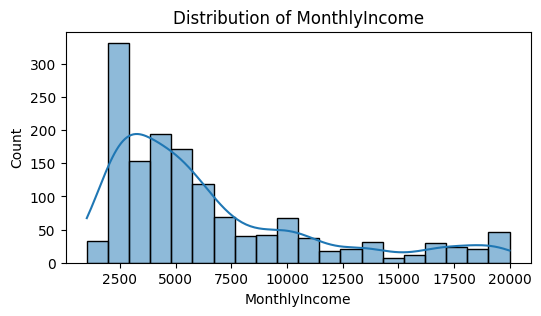

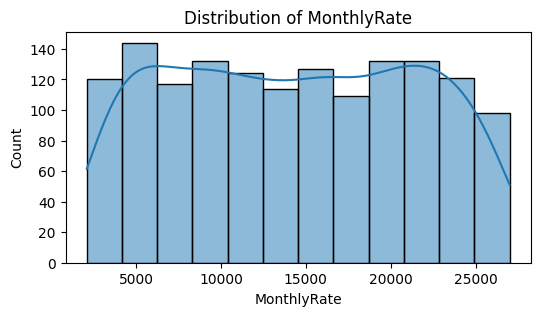

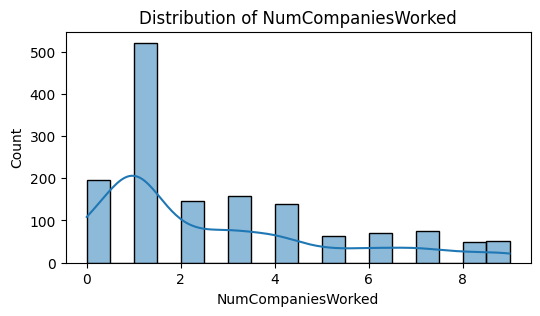

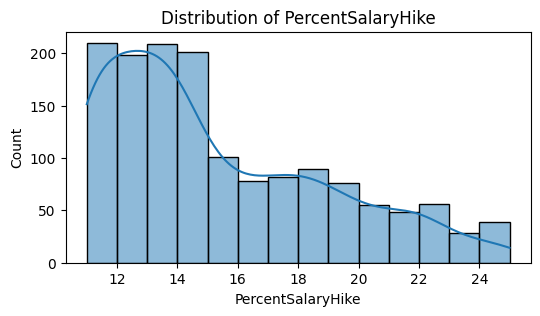

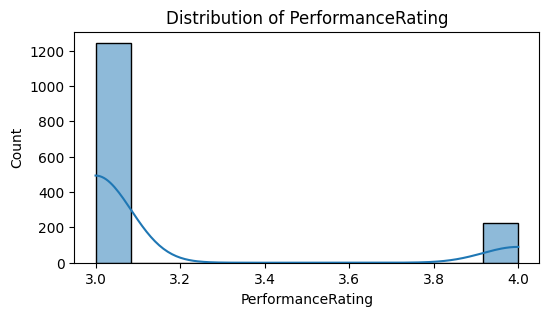

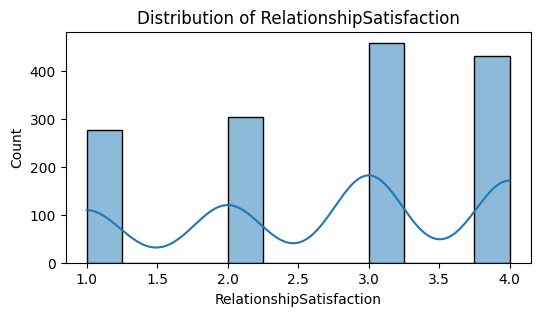

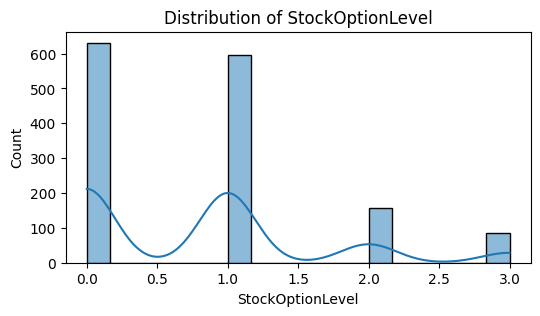

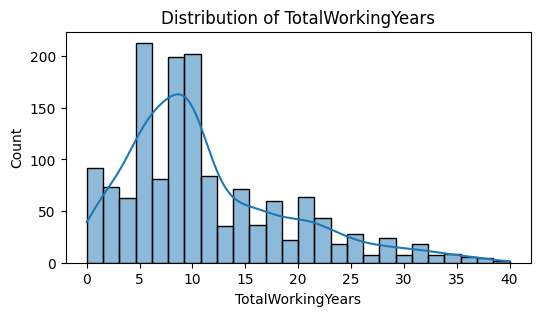

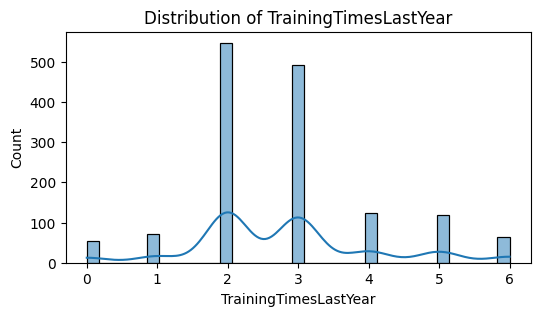

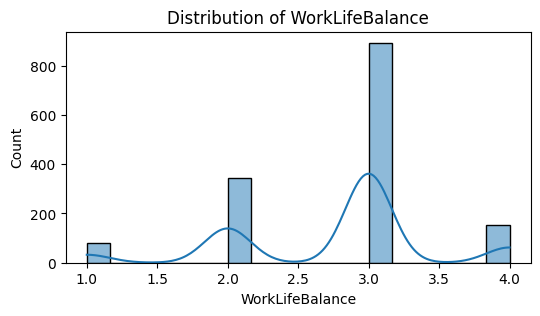

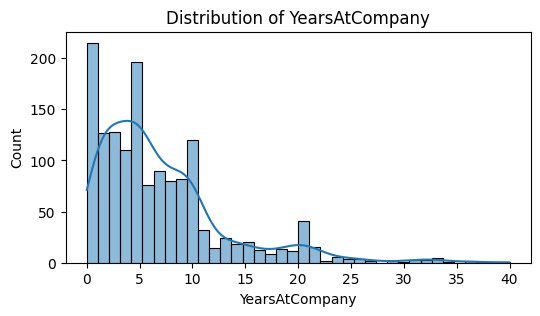

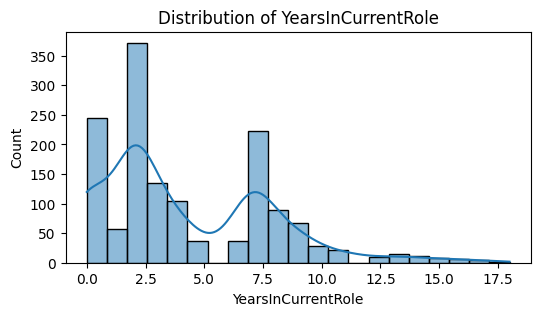

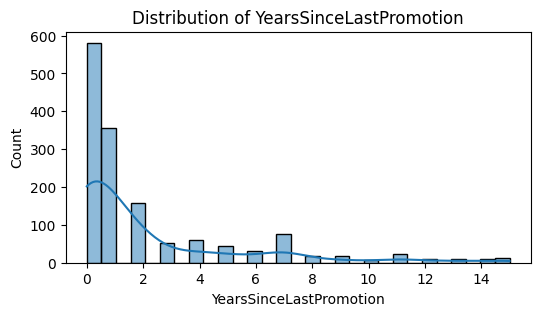

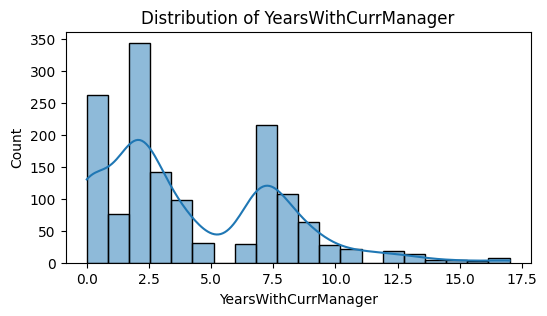

In [7]:
for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

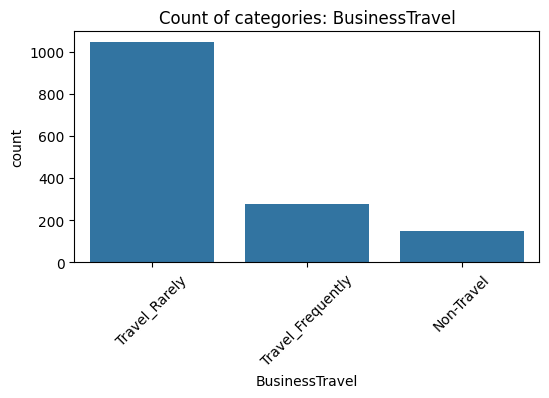

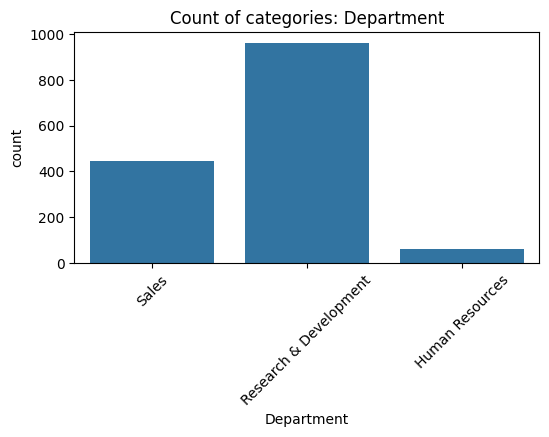

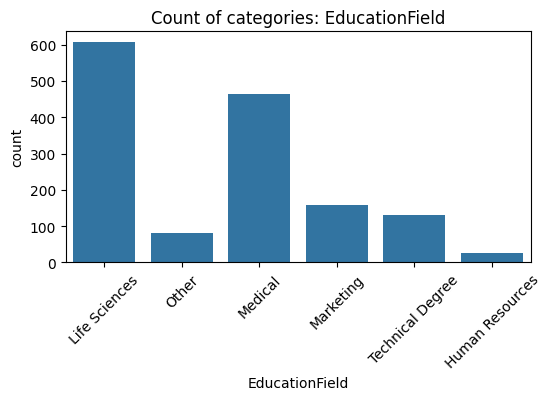

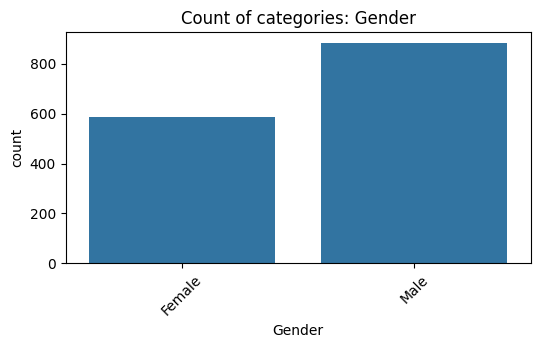

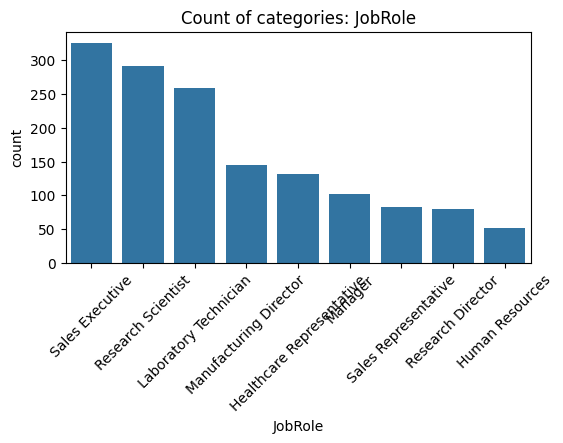

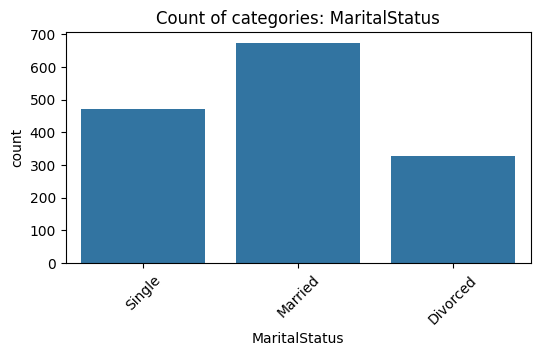

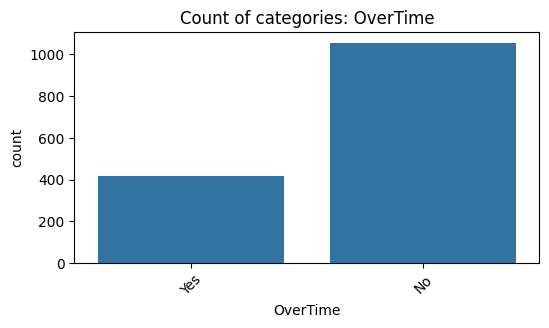

In [8]:
for col in categorical_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(data=df, x=col)
    plt.title(f"Count of categories: {col}")
    plt.xticks(rotation=45)
    plt.show()

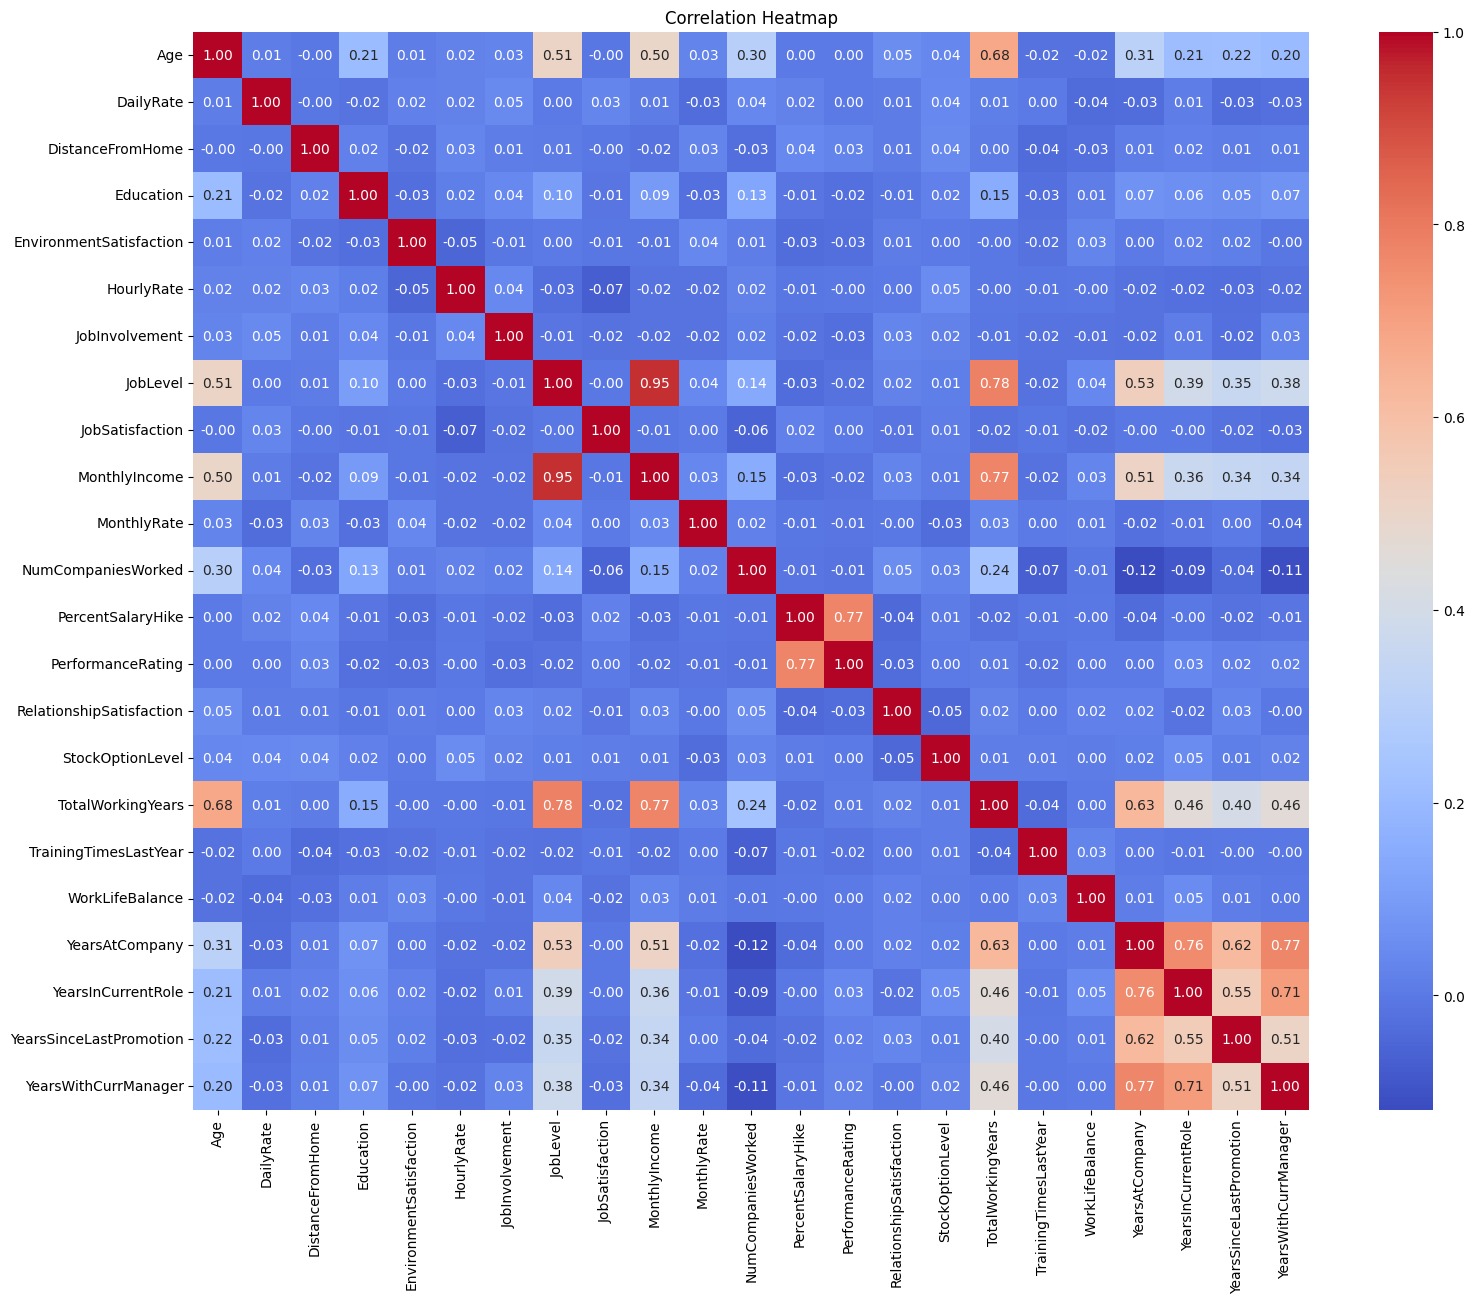

In [9]:
plt.figure(figsize=(18, 14))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

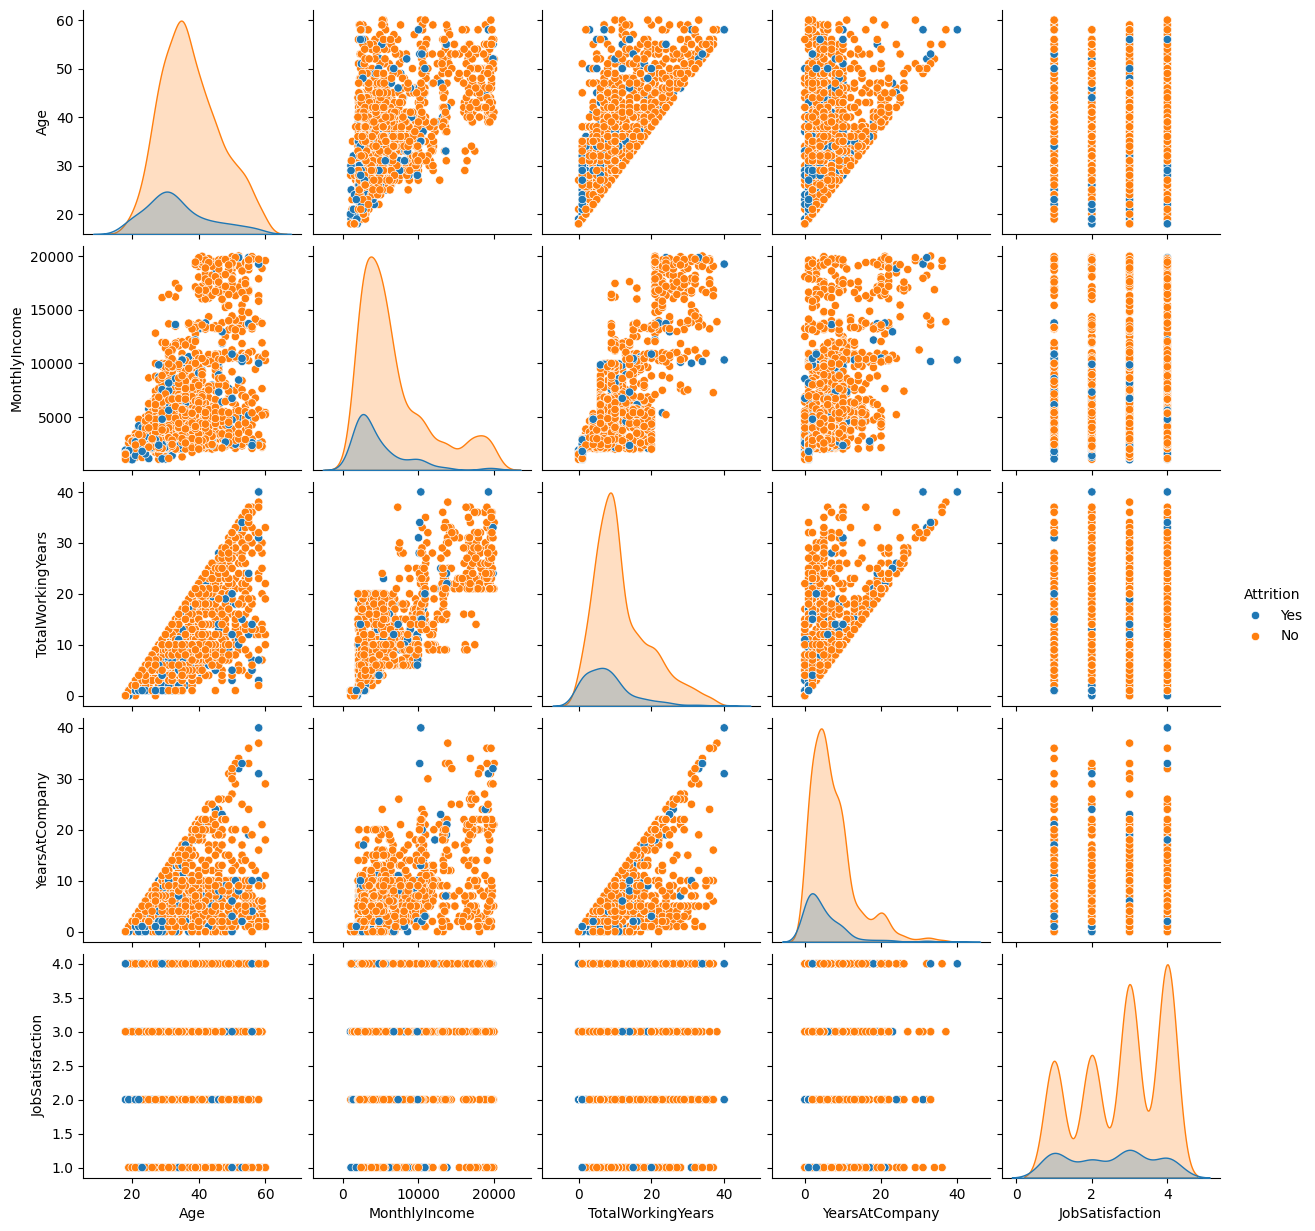

In [10]:
sns.pairplot(df[['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'JobSatisfaction', 'Attrition']], hue='Attrition')
plt.show()

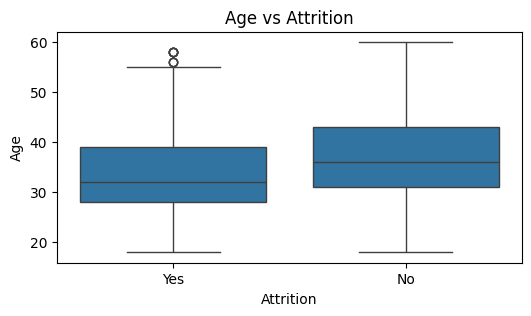

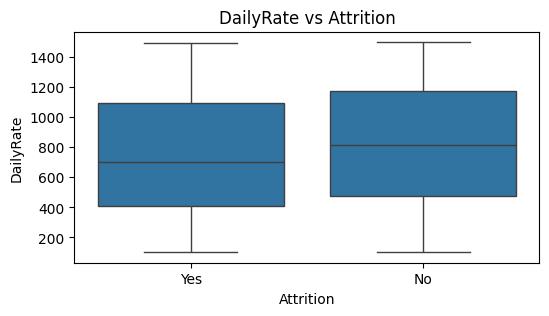

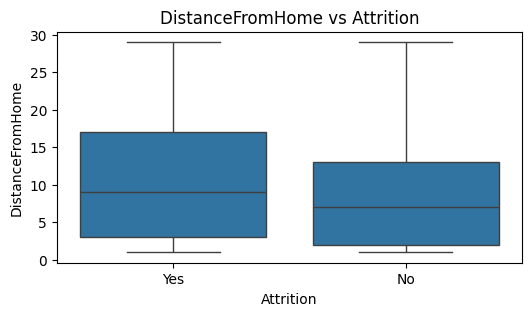

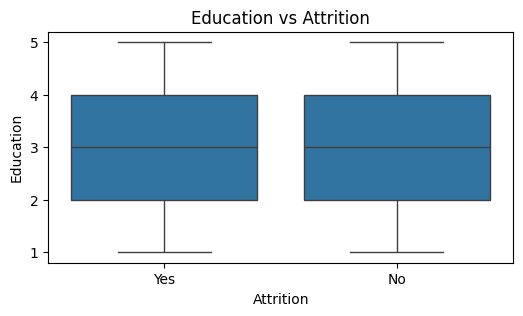

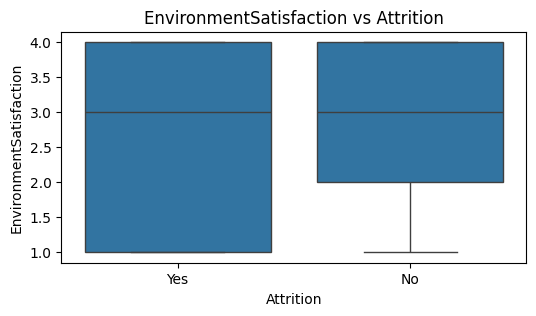

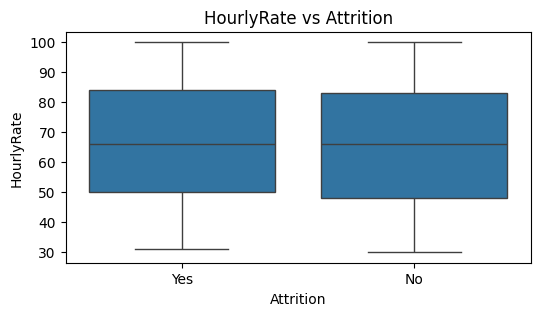

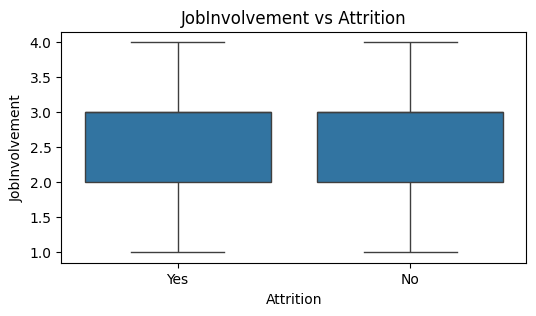

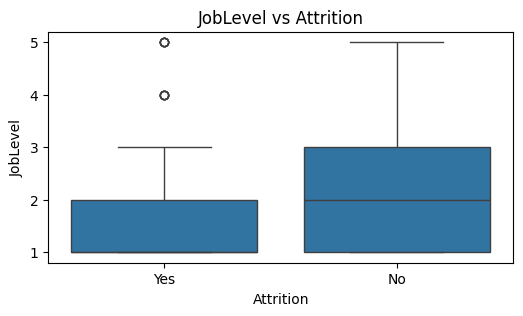

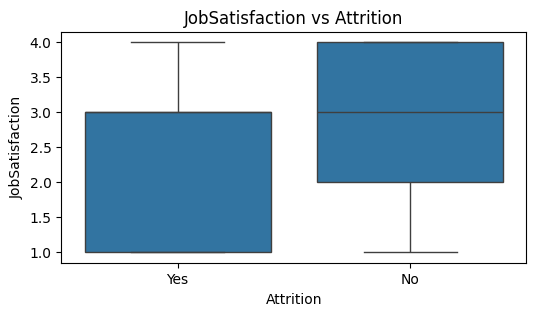

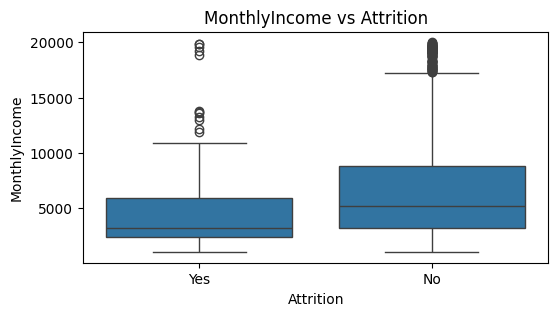

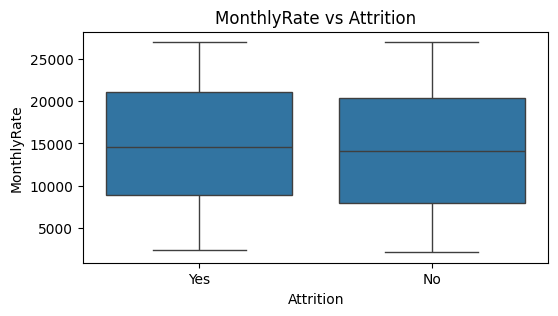

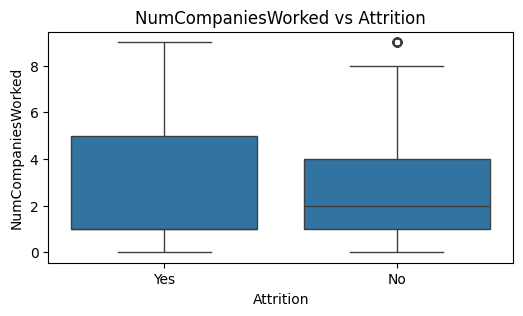

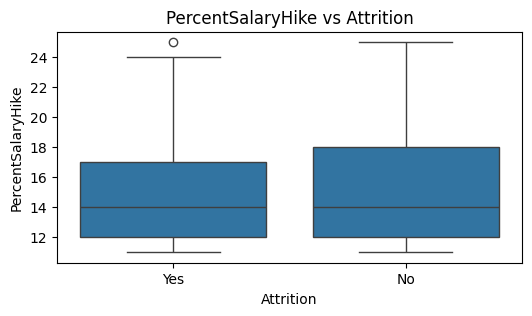

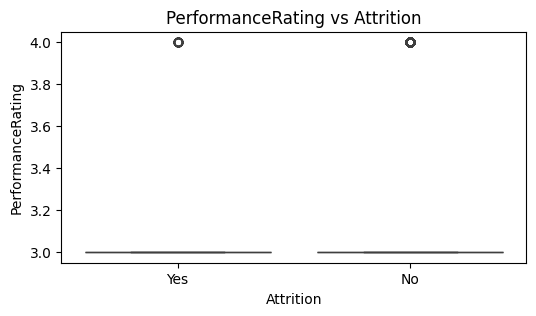

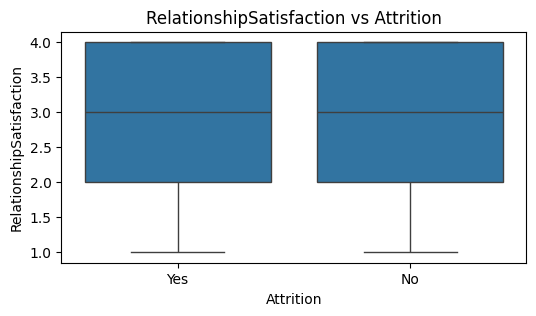

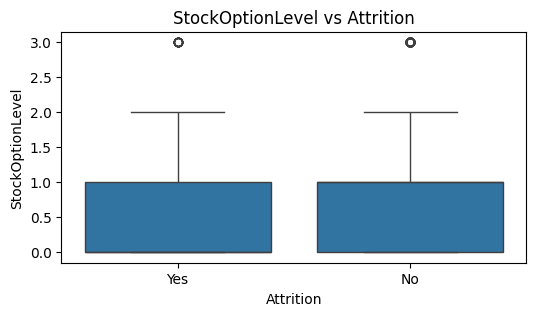

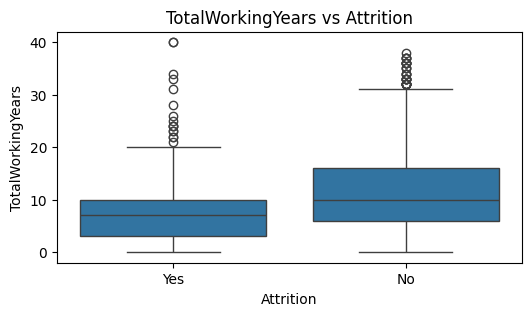

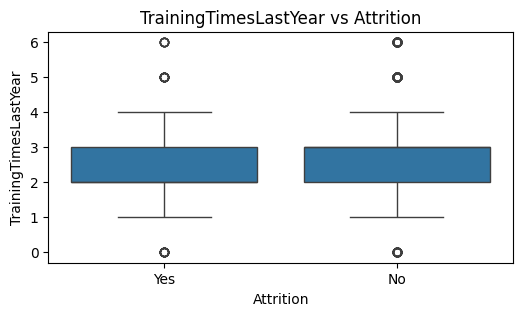

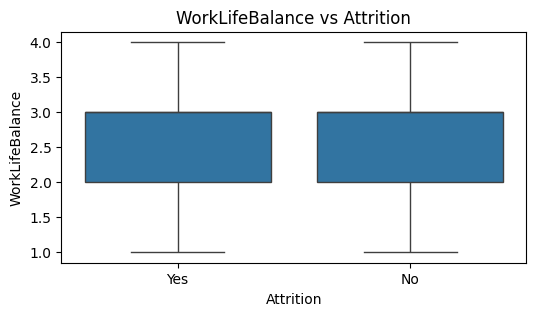

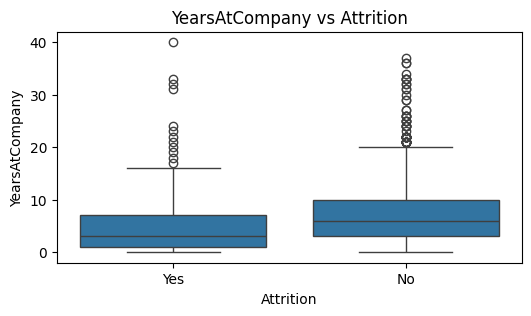

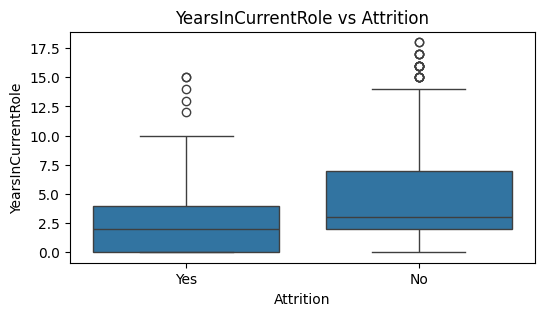

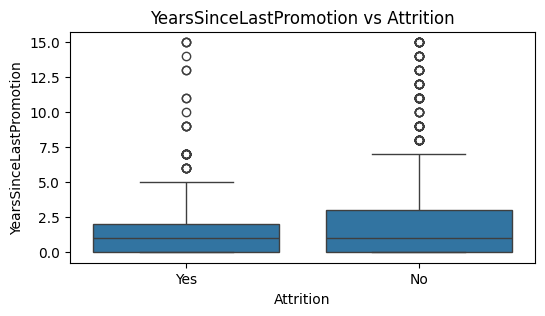

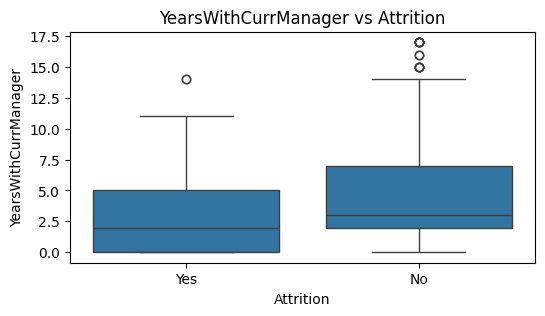

In [11]:
for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x='Attrition', y=col, data=df)
    plt.title(f"{col} vs Attrition")
    plt.show()

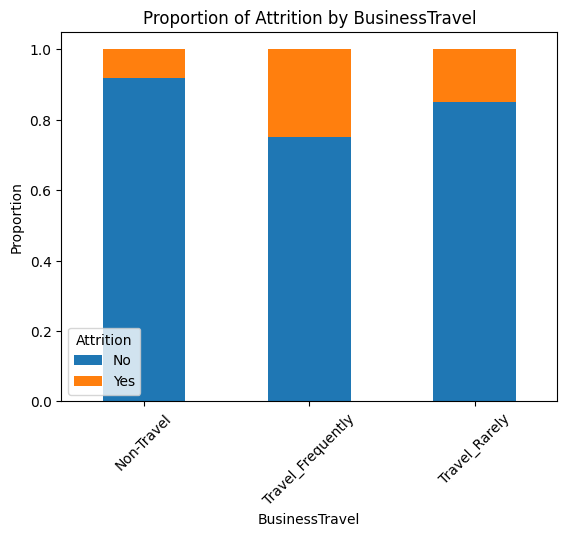

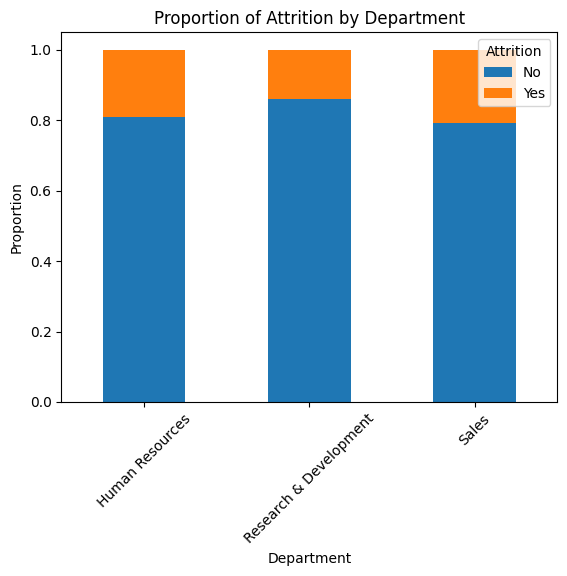

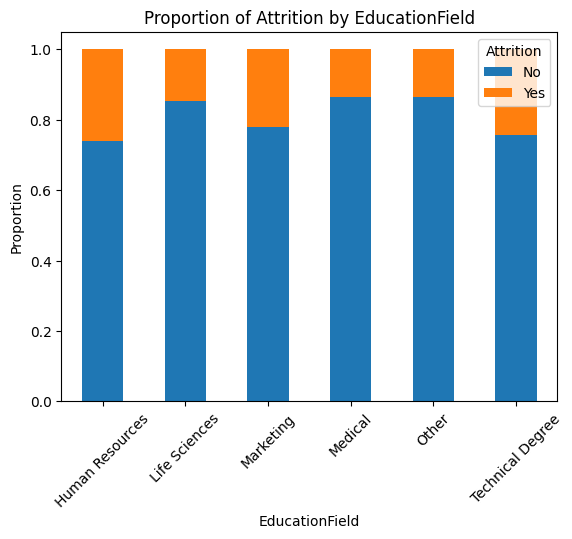

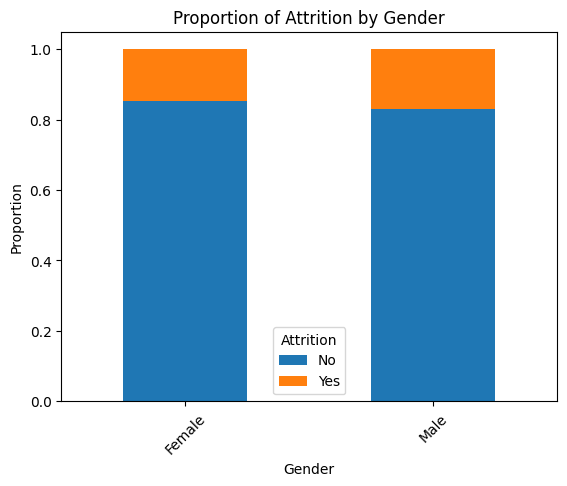

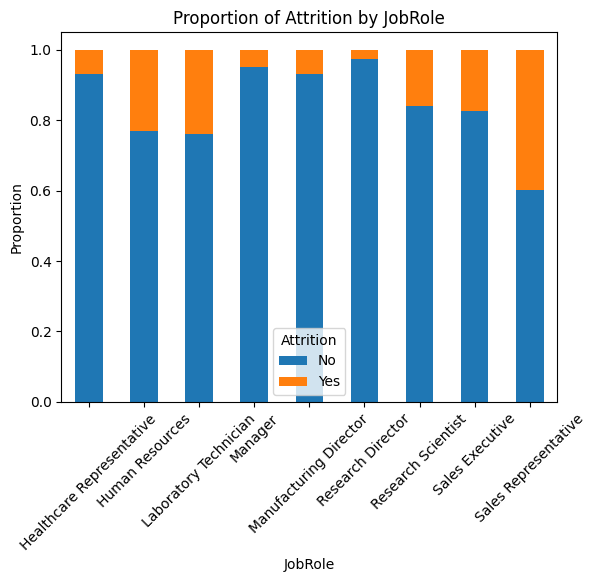

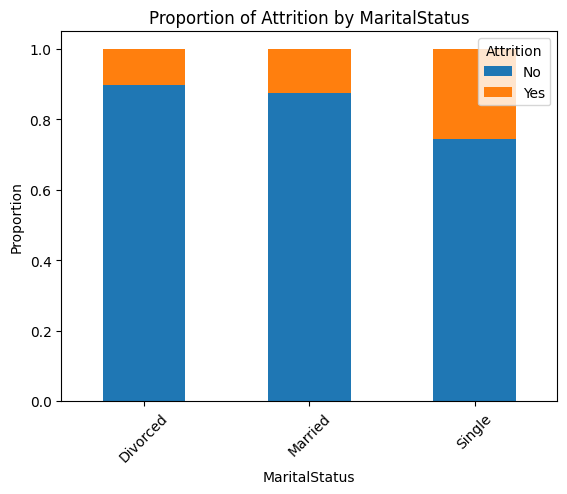

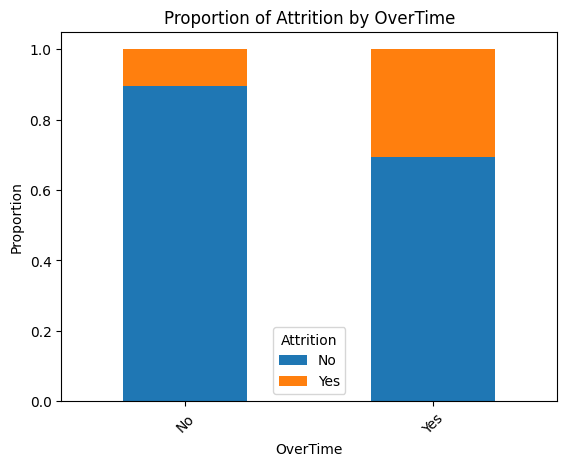

In [12]:
for col in categorical_cols:
    cross_tab = pd.crosstab(df[col], df['Attrition'], normalize='index')
    cross_tab.plot(kind='bar', stacked=True)
    plt.title(f"Proportion of Attrition by {col}")
    plt.ylabel("Proportion")
    plt.legend(title="Attrition", loc="best")
    plt.xticks(rotation=45)
    plt.show()

## 3. Preprocessing

In [13]:
from sklearn.preprocessing import LabelEncoder

column_classification = "Attrition"
df_encoded = df.copy()

# Label encode target: Yes -> 1, No -> 0
le_target = LabelEncoder()
df_encoded[column_classification] = le_target.fit_transform(df[column_classification])

# One-hot encode categorical features
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

print("Encoded shape:", df_encoded.shape)
df_encoded.head()

Encoded shape: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False


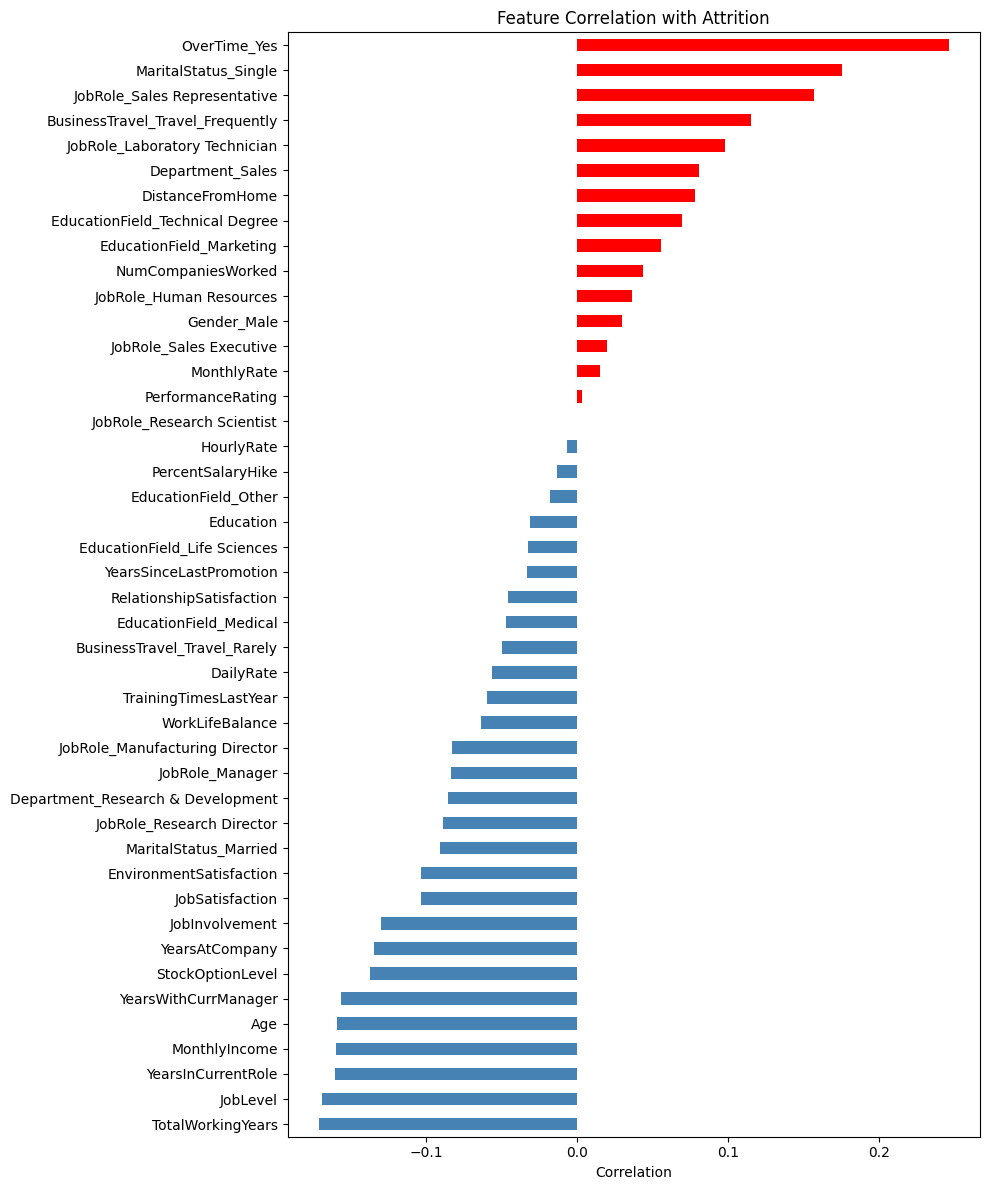

In [14]:
# Correlation of each feature with Attrition
feature_correlation = df_encoded.drop(column_classification, axis=1).corrwith(df_encoded[column_classification]).sort_values()

plt.figure(figsize=(10, 12))
feature_correlation.plot(kind='barh', color=feature_correlation.map(lambda x: 'red' if x > 0 else 'steelblue'))
plt.title("Feature Correlation with Attrition")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

## 4. Dimensionality Reduction (PCA + SVD)

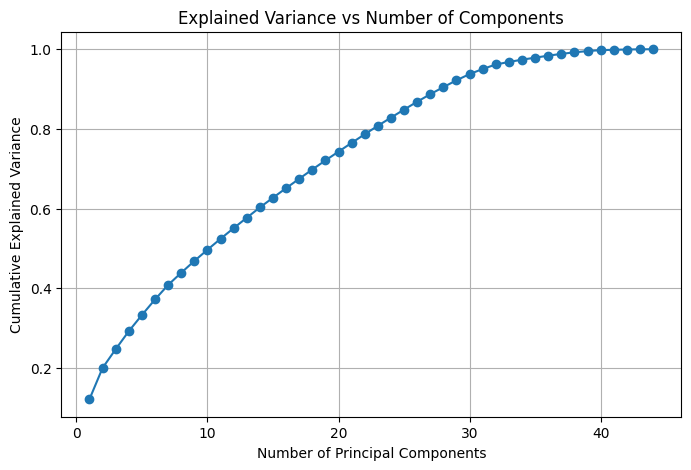

Components to explain 95% variance: 31
Explained variance ratio: [0.12130945 0.07848152]


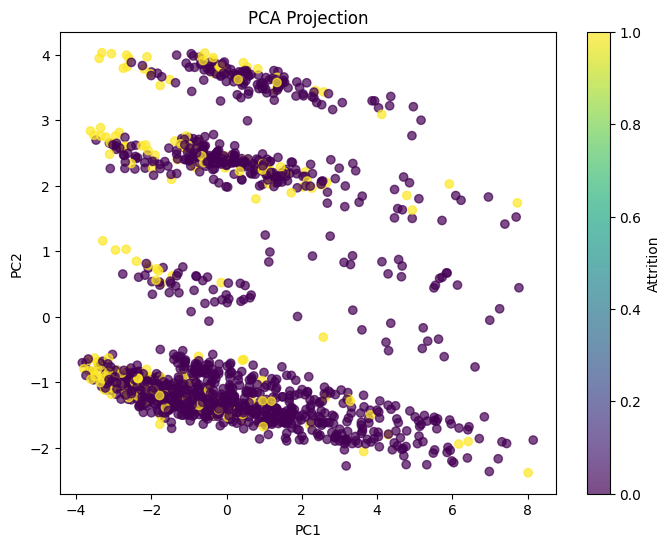

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(column_classification, axis=1)
y = df_encoded[column_classification]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Cumulative explained variance
pca_full = PCA().fit(X_scaled)
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_var)+1), cumulative_var, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.grid(True)
plt.show()

n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Components to explain 95% variance: {n_components_95}")

# PCA 2D projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection')
plt.colorbar(label='Attrition')
plt.show()

## 5. Modeling


Logistic Regression — Accuracy: 0.8605 | ROC-AUC: 0.8079
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294


Random Forest — Accuracy: 0.8333 | ROC-AUC: 0.7828
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294


SVM — Accuracy: 0.8673 | ROC-AUC: 0.8139
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       247
           1       0.90      0.19      0.32        47

    accuracy                  

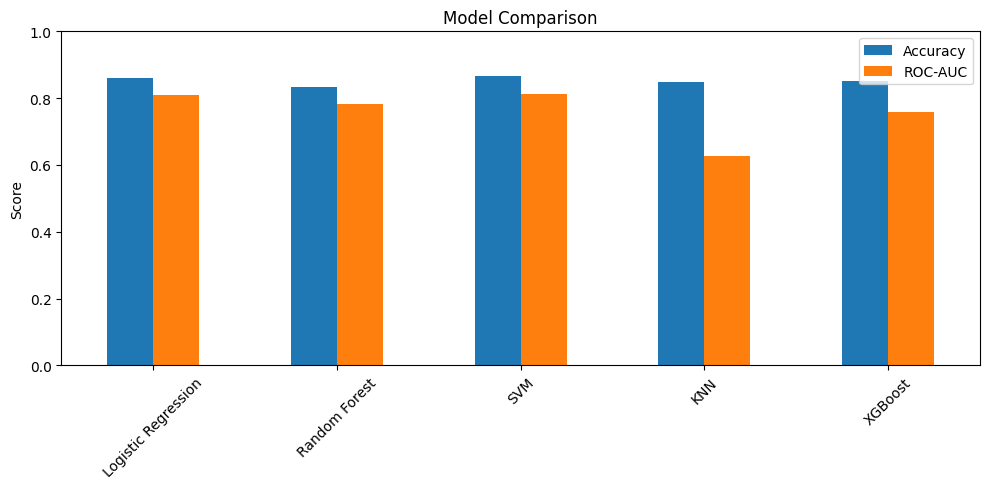

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"\n{name} — Accuracy: {acc:.4f} | ROC-AUC: {roc:.4f}")
    print(classification_report(y_test, y_pred))
    results[name] = {'Accuracy': acc, 'ROC-AUC': roc}

results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(10, 5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 6. GridSearchCV


Running GridSearchCV for Logistic Regression...


Best params: {'C': 0.1, 'solver': 'lbfgs'}
Best CV ROC-AUC: 0.8382

Running GridSearchCV for Random Forest...
Best params: {'max_depth': None, 'n_estimators': 200}
Best CV ROC-AUC: 0.7988

Running GridSearchCV for SVM...
Best params: {'C': 0.1, 'kernel': 'linear'}
Best CV ROC-AUC: 0.8404

Running GridSearchCV for KNN...
Best params: {'n_neighbors': 7, 'weights': 'distance'}
Best CV ROC-AUC: 0.7068

Running GridSearchCV for XGBoost...
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best CV ROC-AUC: 0.7918

Logistic Regression — Accuracy: 0.8639 | ROC-AUC: 0.8083
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.64      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.76      0.65      0.68       294
weighted avg       0.85      0.86      0.85       294


Random Forest — Accuracy: 0.8299 | ROC-AUC: 0.7991
              precision    re

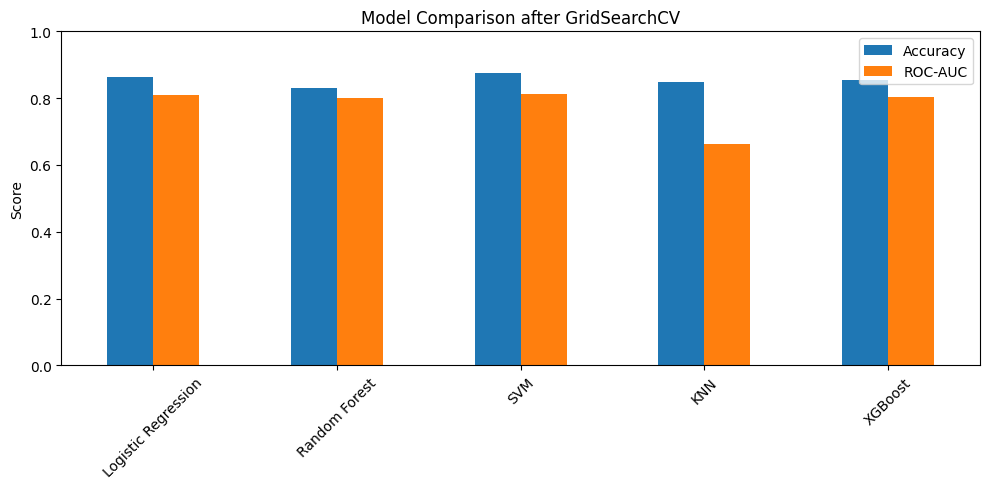

In [17]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs"]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 5, 10]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["rbf", "linear"]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7],
        "weights": ["uniform", "distance"]
    },
    "XGBoost": {
        "n_estimators": [50, 100],
        "max_depth": [3, 5],
        "learning_rate": [0.01, 0.1]
    }
}

best_estimators = {}
for name, model in models.items():
    print(f"\nRunning GridSearchCV for {name}...")
    grid = GridSearchCV(model, param_grids[name], cv=3, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")
    best_estimators[name] = grid.best_estimator_

# Evaluate best models on test set
best_results = {}
for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"\n{name} — Accuracy: {acc:.4f} | ROC-AUC: {roc:.4f}")
    print(classification_report(y_test, y_pred))
    best_results[name] = {'Accuracy': acc, 'ROC-AUC': roc}

best_results_df = pd.DataFrame(best_results).T
best_results_df.plot(kind='bar', figsize=(10, 5))
plt.title("Model Comparison after GridSearchCV")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 7. Evaluation — Confusion Matrix & ROC Curves

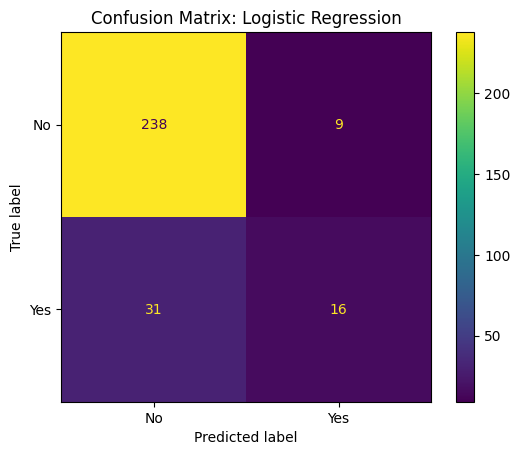

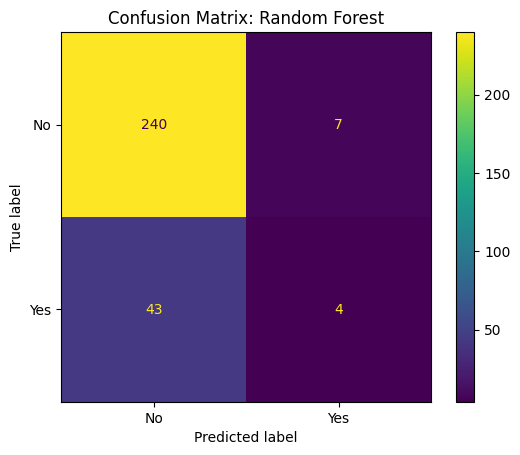

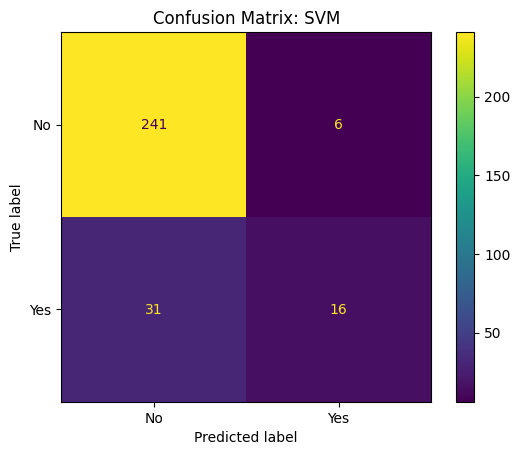

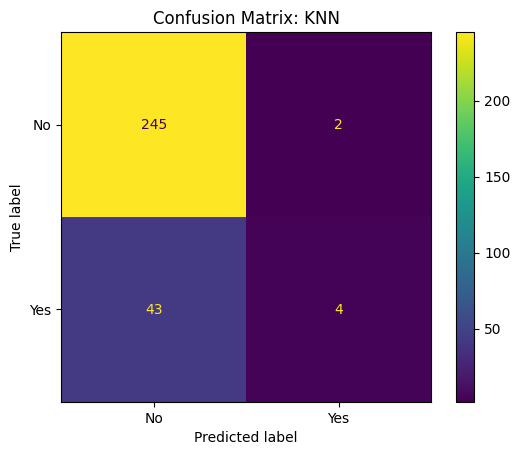

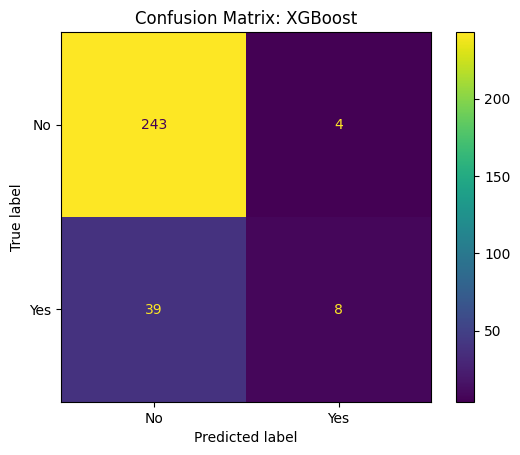

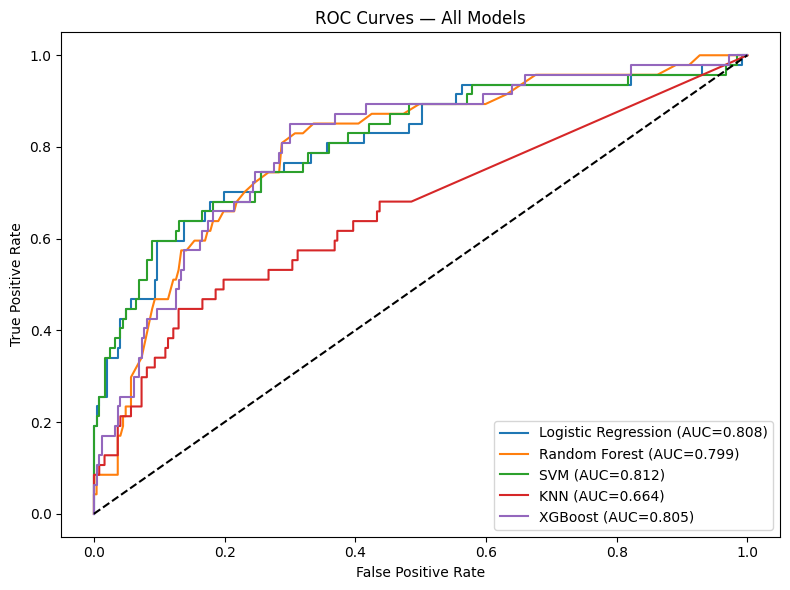

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

# Confusion matrices
for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

# ROC curves — all models on one plot
plt.figure(figsize=(8, 6))
for name, model in best_estimators.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Interpretability — Feature Importance & SHAP

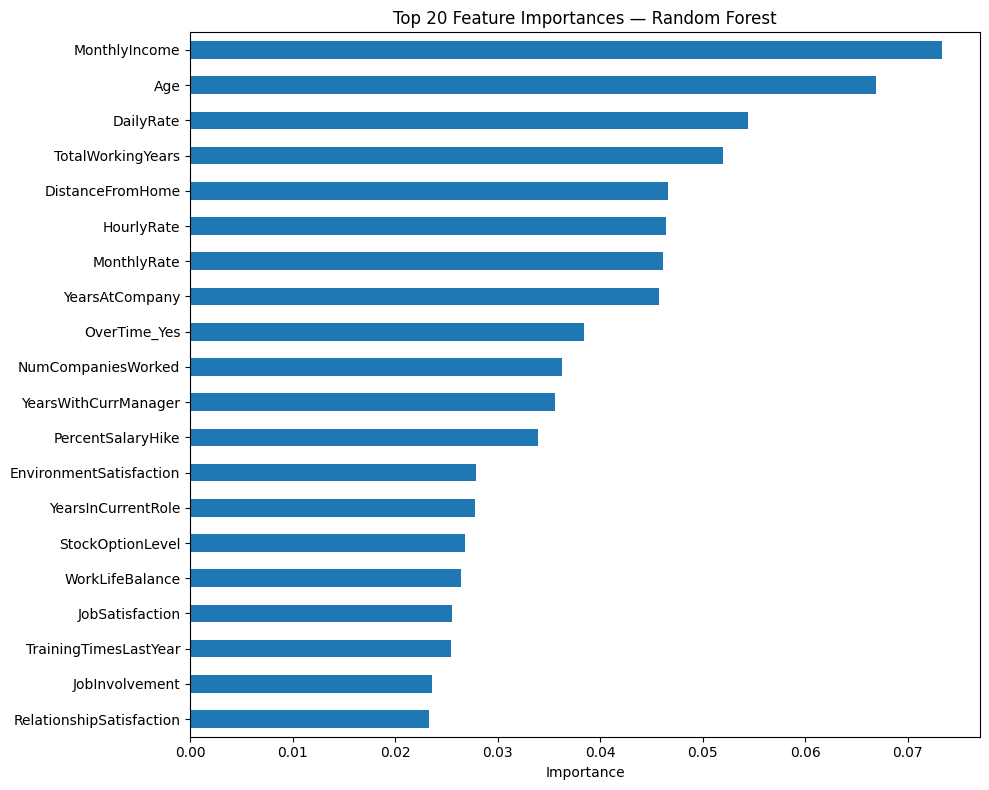

In [19]:
# Random Forest feature importance
importances = best_estimators["Random Forest"].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp[:20].plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

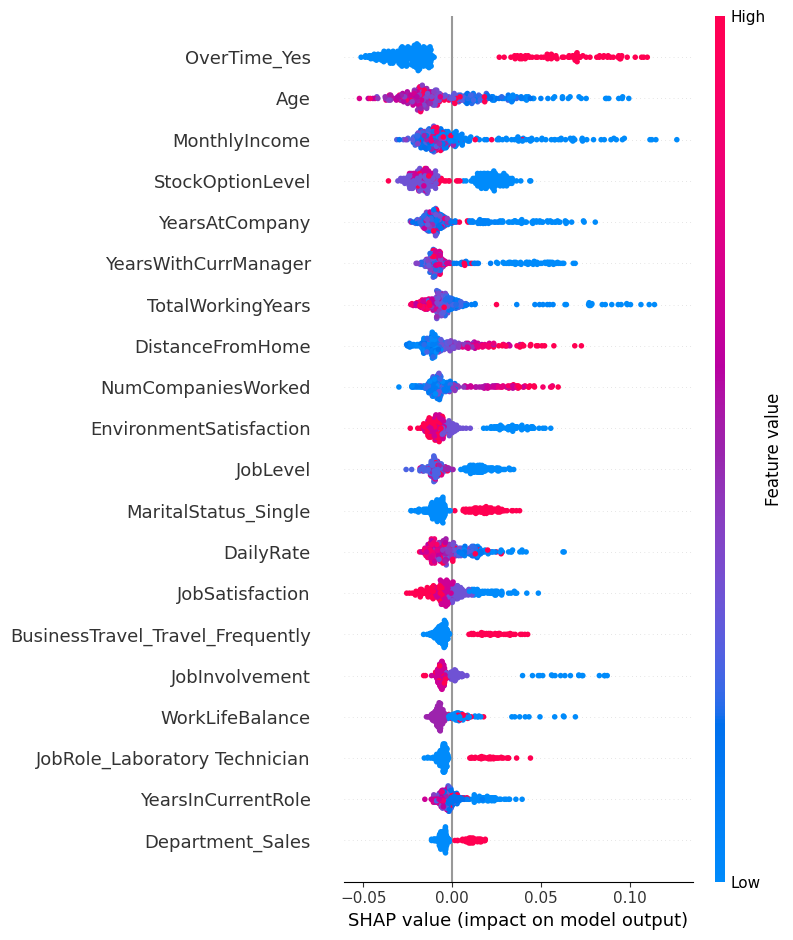

In [20]:
import shap

explainer = shap.TreeExplainer(best_estimators["Random Forest"])
shap_values = explainer.shap_values(X_test)

# Handle both old (list) and new (3D array) SHAP output formats
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values[:, :, 1]

shap.summary_plot(sv, X_test, feature_names=X.columns)